# Project Overview

This project explores a Spotify dataset containing over 114,000 tracks and their audio features. The objective is to clean the dataset and perform exploratory data analysis (EDA) in order to better understand patterns in song popularity, genre distribution, track duration, and various audio characteristics. The analysis aims to identify trends and insights that can help explain how songs differ across genres and popularity levels.

A summary of the project, research questions, visualizations, and key findings is presented in the accompanying portfolio website.

# Cleaning the Dataset

First, the the dataset must be inspected and prepared before conducting any analysis. Data cleaning helps ensure that the results are based on accurate, consistent, and reliable data. In this section, the dataset is examined for missing values, duplicate records, incorrect data types, and potential inconsistencies.

## Introduction to the Dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshanaasthigiri/spotify-tracks-dataset/spotify-tracks-dataset-detailed.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/lakshanaasthigiri/spotify-tracks-dataset/spotify-tracks-dataset-detailed.csv")

In [3]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
df.tail()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [5]:
df.shape

(114000, 20)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [7]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## Checking Missing Values

In [8]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [9]:
df[df.isnull().any(axis = 1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [10]:
missing_percent = (df.isnull() / len(df)) * 100
missing_percent

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
113996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
113997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
113998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
df = df.dropna()

In [12]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [13]:
df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

## Checking for Duplicate Rows

In [14]:
df.duplicated().sum()

np.int64(450)

In [15]:
df[df.duplicated()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1925,0CDucx9lKxuCZplLXUz0iX,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
2155,2aibwv5hGXSgw7Yru8IYTO,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.116000,0.000017,0.1190,0.599,104.655,4,alt-rock
3738,7mULVp0DJrI2Nd6GesLvxn,Joy Division,Timeless Rock Hits,Love Will Tear Us Apart,0,204621,False,0.524,0.902,2,-8.662,1,0.0368,0.000989,0.695000,0.1370,0.907,146.833,4,alternative
4648,6d3RIvHfVkoOtW1WHXmbX3,Little Symphony,Serenity,Margot,27,45714,False,0.269,0.142,0,-23.695,1,0.0509,0.866000,0.904000,0.1140,0.321,67.872,3,ambient
5769,481beimUiUnMUzSbOAFcUT,SUPER BEAVER,突破口 / 自慢になりたい,突破口,54,255080,False,0.472,0.994,8,-1.786,1,0.1140,0.025900,0.000000,0.0535,0.262,103.512,4,anime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111246,0sSjIvTvd6fUSZZ5rnTPDW,Everything But The Girl,Eden (Deluxe Edition),Another Bridge - 2012 Remaster,26,132826,False,0.480,0.853,0,-6.276,1,0.0734,0.030600,0.000001,0.3200,0.775,85.181,4,trip-hop
111362,2zg3iJW4fK7KZgHOvJU67z,Faithless,Faithless 2.0,Tarantula,21,398152,False,0.622,0.816,6,-11.095,0,0.0483,0.009590,0.578000,0.0991,0.427,136.007,4,trip-hop
111980,46FPub2Fewe7XrgM0smTYI,Morcheeba,Parts of the Process,Undress Me Now,17,203773,False,0.576,0.352,7,-10.773,0,0.0268,0.700000,0.270000,0.1600,0.360,95.484,4,trip-hop
112968,6qVA1MqDrDKfk9144bhoKp,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,4,turkish


In [16]:
df = df.drop_duplicates()

In [17]:
df

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [18]:
df.duplicated().sum()

np.int64(0)

## Checking for Duplicate Track ID's

In [19]:
df["track_id"].duplicated().sum()

np.int64(23809)

In [20]:
duplicate_tracks = df[df["track_id"].duplicated(keep=False)]
duplicate_tracks[["track_id", "track_name", "artists", "track_genre"]].head(20)

,track_id,track_name,artists,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Comedy,Gen Hoshino,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ghost - Acoustic,Ben Woodward,acoustic
5,01MVOl9KtVTNfFiBU9I7dc,Days I Will Remember,Tyrone Wells,acoustic
6,6Vc5wAMmXdKIAM7WUoEb7N,Say Something,A Great Big World;Christina Aguilera,acoustic
7,1EzrEOXmMH3G43AXT1y7pA,I'm Yours,Jason Mraz,acoustic
9,7k9GuJYLp2AzqokyEdwEw2,Hunger,Ross Copperman,acoustic
12,4ptDJbJl35d7gQfeNteBwp,Solo,Dan Berk,acoustic
13,0X9MxHR1rTkEHDjp95F2OO,Bad Liar,Anna Hamilton,acoustic
16,6xKeQgzfjixSUld14qUezm,ily (i love you baby),Andrew Foy;Renee Foy,acoustic
17,4Yo0igmcoNyat1secaH0OD,At My Worst,Andrew Foy;Renee Foy,acoustic


## Checking Column Names & Data Types

In [21]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [22]:
df.columns = df.columns.str.strip()

In [23]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [24]:
df.dtypes

track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Converting Duration to Minutes

In [25]:
df["duration_min"] = df["duration_ms"] / 60000

/tmp/ipykernel_58/3784714997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["duration_min"] = df["duration_ms"] / 60000


In [26]:
df[["duration_ms", "duration_min"]].head()

,duration_ms,duration_min
0,230666,3.844433
1,149610,2.493500
2,210826,3.513767
3,201933,3.365550
4,198853,3.314217


## Checking Duration Outliers

In [27]:
df["duration_min"].describe()

count    113549.000000
mean          3.801356
std           1.773552
min           0.143100
25%           2.903067
50%           3.550000
75%           4.359800
max          87.288250
Name: duration_min, dtype: float64

In [28]:
df.nsmallest(10, "duration_min")[
    ["track_name", "artists", "duration_min"]
]

,track_name,artists,duration_min
59310,The Exorsism Begins...,Leila Bela,0.143100
59812,V-4,Leila Bela,0.223100
59775,Screams for a Finale! (feat. Leila's Opera Class),Leila Bela;Leila's Opera Class,0.263333
16856,"Andante in C Major, K. 1a",Wolfgang Amadeus Mozart;Ingrid Haebler,0.290883
16288,"Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",Robert Schumann;Pavel Nersessian,0.297100
39233,"Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",Robert Schumann;Pavel Nersessian,0.297100
59306,V-7,Leila Bela,0.352000
59609,Shatter,Leila Bela,0.354000
11398,"Cello Suite No. 3, Op. 87: IX. Passacaglia (Ex...",Benjamin Britten;Steven Isserlis,0.371100
16292,"Carnaval, Op. 9: No. 13, Estrella (Live in Jap...",Robert Schumann;Pavel Nersessian,0.391767


In [29]:
df.nlargest(10, "duration_min")[
    ["track_name", "artists", "duration_min"]
]

,track_name,artists,duration_min
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,87.288250
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,79.817100
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,78.838367
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,76.064950
13344,House of Om - Mark Farina - Continuous Mix,Mark Farina,74.125333
13245,Live In Tokyo - Continuous Mix,Mark Farina,72.330433
13195,Greenhouse Construction,Mark Farina,72.245350
27926,"NQ State of Mind, Vol. 1 - Continuous DJ Mix",Lenzman;Dan Stezo,70.770100
101390,Ocean Waves Sounds,Ocean Sounds,68.670967
45063,Internal Flight (Remastered),Estas Tonne,64.604600


## Checking Feature Ranges

In [30]:
audio_features = ["danceability", "energy", "speechiness", "acousticness", "instrumentalness", "liveness", "valence"]

for feature in audio_features:
    print(feature, df[feature].min(), df[feature].max())

danceability 0.0 0.985
energy 0.0 1.0
speechiness 0.0 0.965
acousticness 0.0 0.996
instrumentalness 0.0 1.0
liveness 0.0 1.0
valence 0.0 0.995


## Checking Popularity

In [31]:
df["popularity"].describe()

count    113549.000000
mean         33.324433
std          22.283855
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

In [32]:
df[
    (df["popularity"] < 0) |
    (df["popularity"] > 100)
]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min


## Checking Tempo

In [33]:
df["tempo"].describe()

count    113549.000000
mean        122.175745
std          29.972954
min           0.000000
25%          99.296000
50%         122.020000
75%         140.074000
max         243.372000
Name: tempo, dtype: float64

In [34]:
df.nlargest(10, "tempo")[
    ["track_name", "tempo"]
]

,track_name,tempo
8619,Call The Doctor,243.372
111908,Undenied,222.605
26681,Hip Hip Pooh Rah,220.525
26638,Heffalumps and Woozles,220.084
1087,Makoti,220.081
1136,Makoti,220.081
1144,Makoti,220.081
94759,Goodbye to a world,220.039
59251,When There Was Nothing,219.971
10195,Feel Like Jumpin - Krossbow Remix,219.693


## Checking Genres

In [35]:
df["track_genre"].nunique()

114

In [36]:
df["track_genre"].value_counts()

track_genre
acoustic      1000
british       1000
electronic    1000
emo           1000
funk          1000
              ... 
honky-tonk     981
dance          965
german         963
classical      933
romance        904
Name: count, Length: 114, dtype: int64

# Exploratory Data Analysis

After cleaning the dataset, exploratory data analysis is performed to better understand the characteristics of Spotify tracks. This stage focuses on identifying patterns, distributions, relationships, and potential trends within the data using summary statistics and visualizations.

## What does this dataset contain?

In [37]:
print(f"Number of songs: {len(df):,}")
print(f"Number of artists: {df['artists'].nunique():,}")
print(f"Number of albums: {df['album_name'].nunique():,}")
print(f"Number of genres: {df['track_genre'].nunique():,}")

Number of songs: 113,549
Number of artists: 31,437
Number of albums: 46,589
Number of genres: 114


## Are most Spotify songs popular?

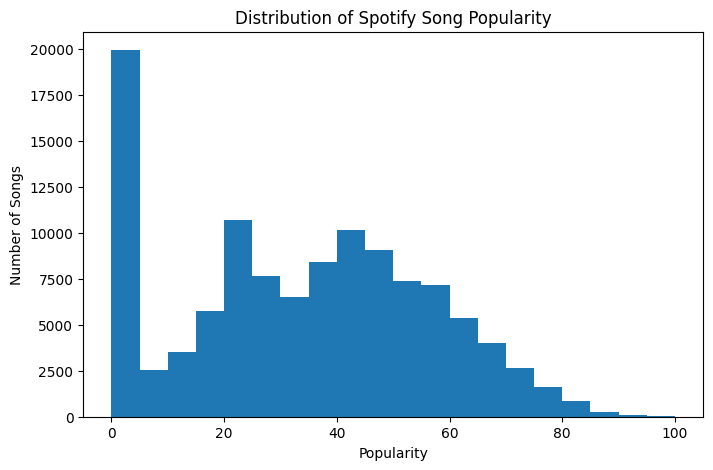

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["popularity"], bins=20)
plt.title("Distribution of Spotify Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.show()

In [39]:
df["popularity"].describe()

count    113549.000000
mean         33.324433
std          22.283855
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

## What genres have the most songs?

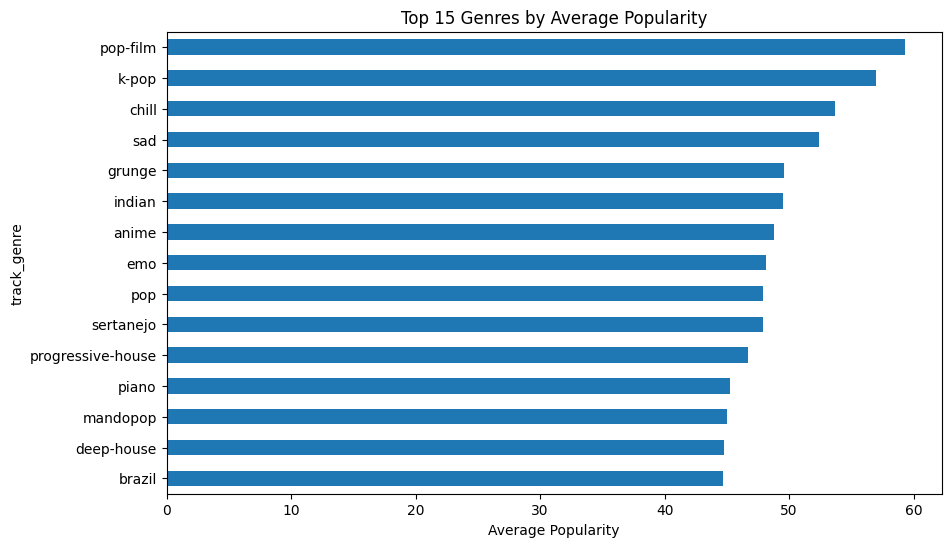

In [40]:
genre_popularity = (
    df.groupby("track_genre")["popularity"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))
genre_popularity.sort_values().plot(kind="barh")
plt.title("Top 15 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.show()

## How long are Spotify songs typically?

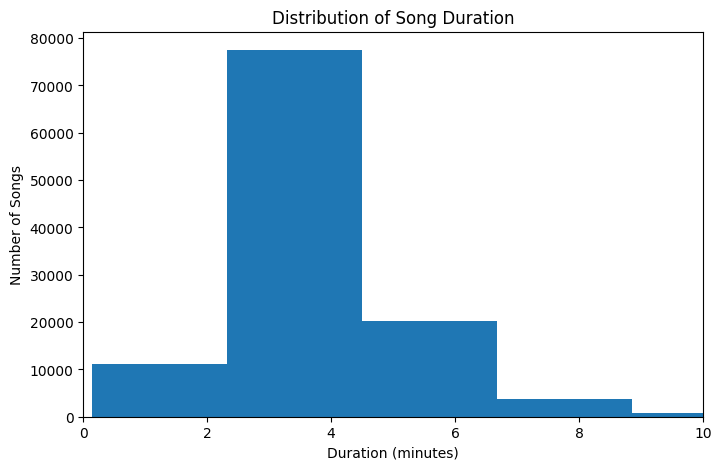

In [41]:
plt.figure(figsize=(8,5))
plt.hist(df["duration_min"], bins=40)
plt.xlim(0,10)
plt.title("Distribution of Song Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Songs")
plt.show()

In [42]:
df["duration_min"].describe()

count    113549.000000
mean          3.801356
std           1.773552
min           0.143100
25%           2.903067
50%           3.550000
75%           4.359800
max          87.288250
Name: duration_min, dtype: float64

## What are the distributions for features such as danceability, energy, valence, acousticness, and speechiness?

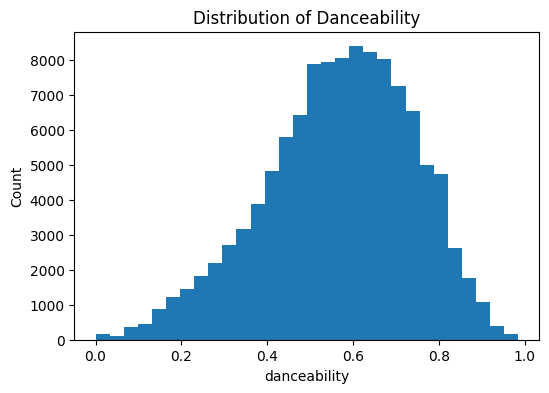

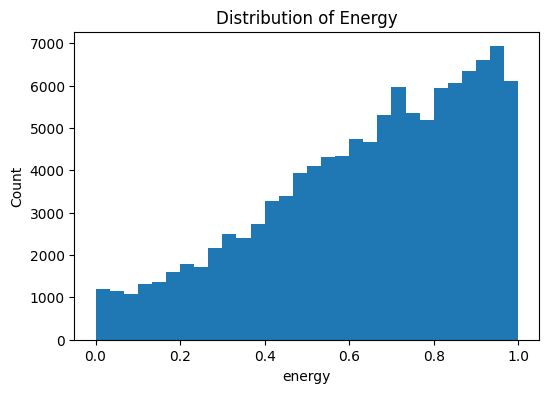

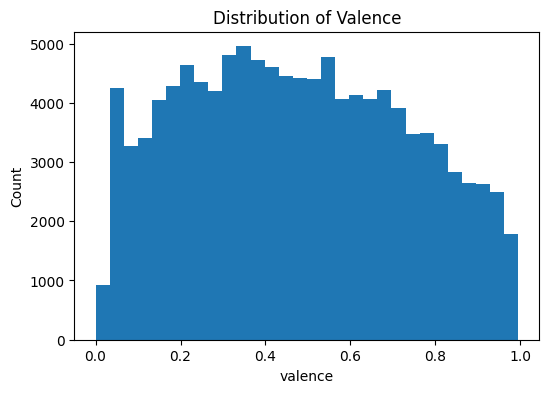

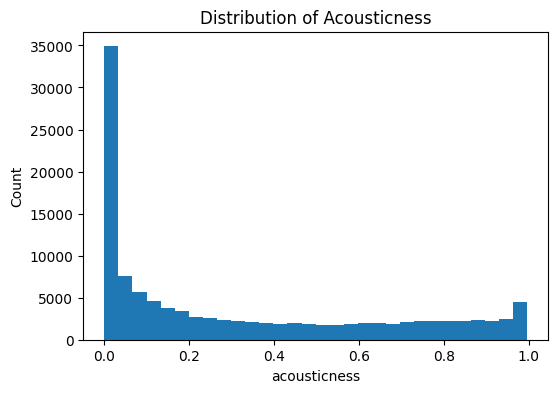

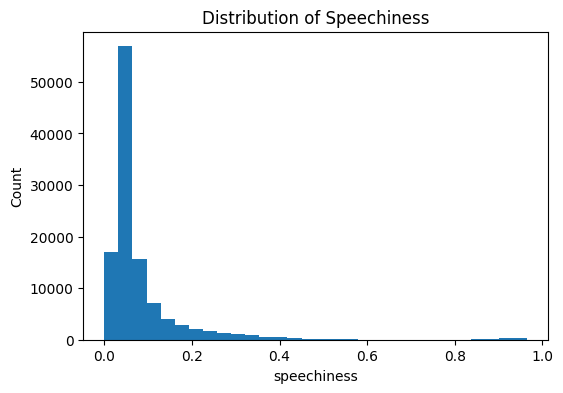

In [43]:
features = ["danceability", "energy", "valence", "acousticness", "speechiness"]

for feature in features:
    plt.figure(figsize=(6,4))
    plt.hist(df[feature], bins=30)
    plt.title(f"Distribution of {feature.capitalize()}")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

## What numerical features are related?

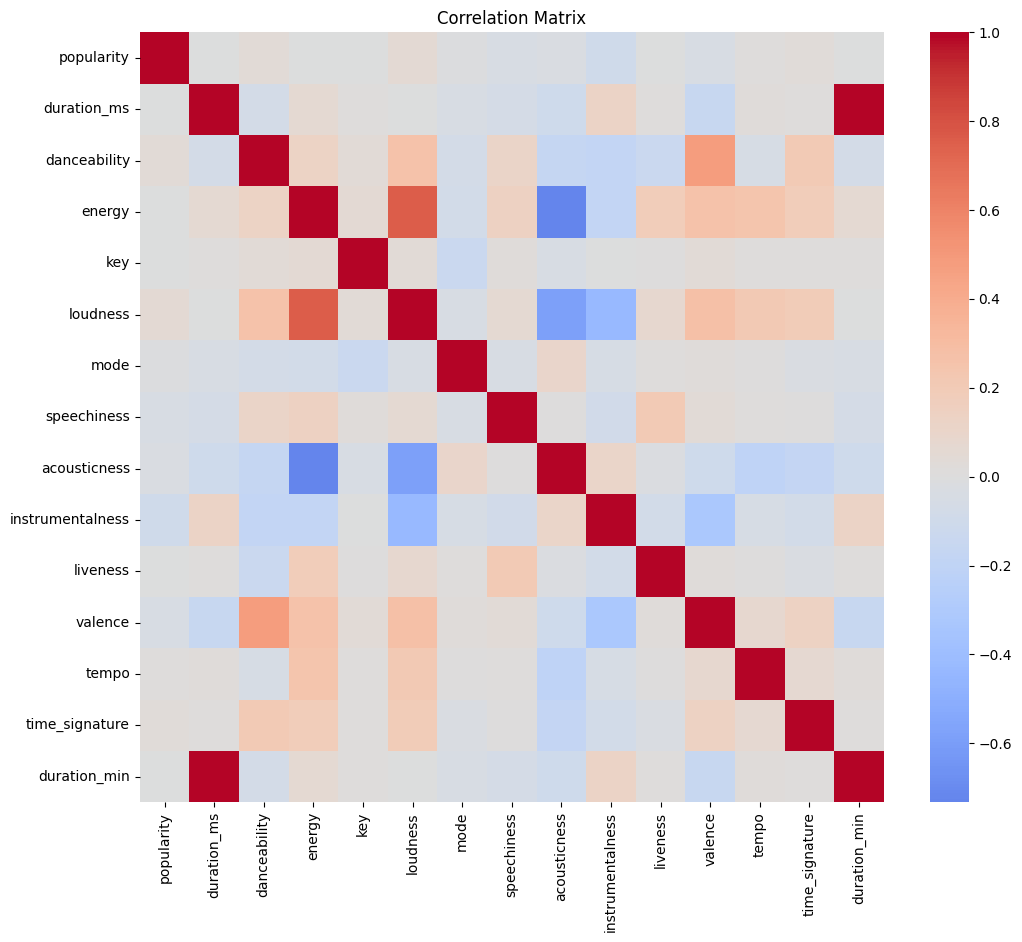

In [44]:
import seaborn as sns

plt.figure(figsize=(12,10))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [45]:
audio_features = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]

popularity_corr = df[audio_features + ["popularity"]].corr()["popularity"].sort_values(ascending=False)

popularity_corr = popularity_corr.drop("popularity")

popularity_corr

loudness            0.047368
danceability        0.034407
tempo               0.012187
energy             -0.002447
liveness           -0.005668
acousticness       -0.022356
valence            -0.041097
speechiness        -0.045463
instrumentalness   -0.094718
Name: popularity, dtype: float64

## Do popular songs and less popular songs differ in their audio characteristics?

In [46]:
df["popularity_group"] = df["popularity"].apply(lambda x: "Popular" if x > 35 else "Less Popular")

group_means = df.groupby("popularity_group")[audio_features].mean()

group_means

/tmp/ipykernel_58/3401978977.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["popularity_group"] = df["popularity"].apply(lambda x: "Popular" if x > 35 else "Less Popular")


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity_group,,,,,,,,,
Less Popular,0.557230,0.648934,-8.465058,0.093982,0.315600,0.186064,0.214887,0.484930,121.833214
Popular,0.577281,0.634934,-8.011603,0.074941,0.312457,0.123951,0.212280,0.462989,122.533969


## Do explicit songs differ from non-explicit songs?

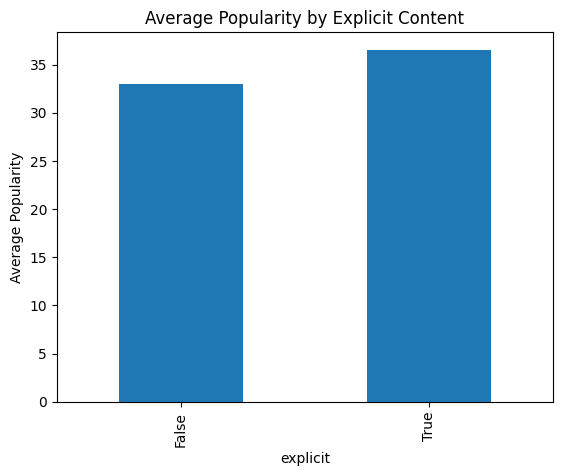

In [47]:
df.groupby("explicit")["popularity"].mean().plot(kind="bar")

plt.title("Average Popularity by Explicit Content")
plt.ylabel("Average Popularity")
plt.show()

## Who are the most popular artists?

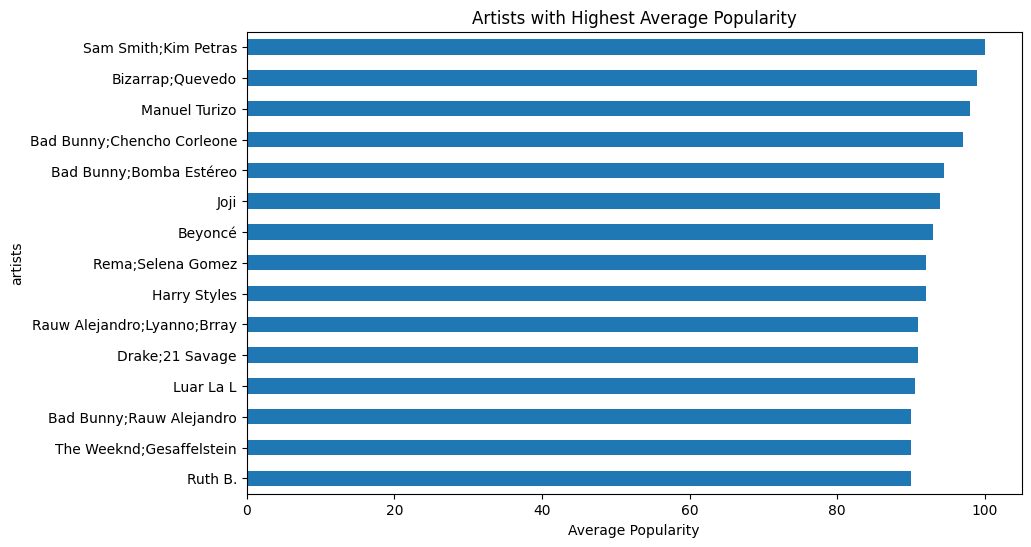

In [48]:
top_artists = (
    df.groupby("artists")["popularity"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

top_artists.sort_values().plot(kind="barh", figsize=(10,6))

plt.title("Artists with Highest Average Popularity")
plt.xlabel("Average Popularity")
plt.show()

This notebook demonstrated the process of cleaning and exploring a large Spotify dataset through exploratory data analysis. The insights and key findings from this analysis are summarized separately as part of the accompanying portfolio project.